BLOQUE 1: INSTALACIONES

In [1]:
!pip install -q kaggle pandas numpy matplotlib seaborn
!pip install -q transformers torch
!pip install -q sentence-transformers chromadb
!pip install -q scikit-learn
!pip install -q tensorflow keras
!pip install -q langchain-mistralai

print(" Instalaciones completadas")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the so

BLOQUE 2: IMPORTACIONES

In [2]:
import os
import json
import zipfile
import re
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Para modelos de ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Para LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Para DistilBERT
from transformers import pipeline

# Para embeddings y vectorstore
from sentence_transformers import SentenceTransformer
import chromadb

# Para Mistral (única importación de LangChain que funciona)
from langchain_mistralai import ChatMistralAI

from google.colab import userdata

print(" Importaciones completadas")

 Importaciones completadas


BLOQUE 3: CONFIGURACIÓN INICIAL

In [3]:
N_MUESTRA_DATASET = 10000
N_CORPUS_RAG = 1500
RANDOM_STATE = 42
MAX_PALABRAS = 5000
MAX_LONGITUD = 200
EPOCAS_LSTM = 5

print(f"   Configuración cargada")
print(f"   Muestra dataset: {N_MUESTRA_DATASET}")
print(f"   Corpus RAG: {N_CORPUS_RAG}")
print(f"   Épocas LSTM: {EPOCAS_LSTM}")

   Configuración cargada
   Muestra dataset: 10000
   Corpus RAG: 1500
   Épocas LSTM: 5


BLOQUE 4: CARGAR DATASET (KAGGLE)

In [4]:
KAGGLE_USERNAME = userdata.get("KAGGLE_USERNAME")
KAGGLE_KEY = userdata.get("KAGGLE_KEY")

if not KAGGLE_USERNAME or not KAGGLE_KEY:
    raise ValueError(" Faltan credenciales Kaggle")

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d snap/amazon-fine-food-reviews

with zipfile.ZipFile("amazon-fine-food-reviews.zip", "r") as zip_ref:
    zip_ref.extractall("amazon_reviews")

df_original = pd.read_csv("amazon_reviews/Reviews.csv")
print(f" Dataset cargado: {df_original.shape[0]} filas, {df_original.shape[1]} columnas")
print(df_original.head())

Dataset URL: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews
License(s): CC0-1.0
100% 242M/242M [00:03<00:00, 77.8MB/s]

 Dataset cargado: 568454 filas, 10 columnas
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0   

BLOQUE 5: AGENTE 1 - NORMALIZADOR (limpieza de datos)


 AGENTE 1: NORMALIZADOR
 Muestra reducida a: (10000, 10)
 Duplicados eliminados: 0

 Dataset balanceado: (2796, 13)
   Positivos: 1398
   Negativos: 1398


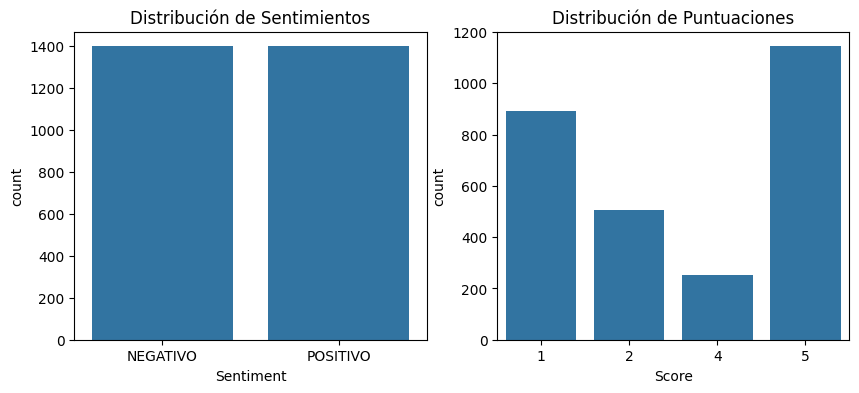

In [5]:
class AgenteNormalizador:
    """Agente 1: Limpieza y normalización de datos"""

    def __init__(self, dataframe, n_muestra=10000):
        self.df = dataframe.copy()
        self.n_muestra = n_muestra

    def limpiar_texto(self, texto):
        """Limpieza básica de texto"""
        if not isinstance(texto, str):
            return ""
        texto = texto.lower()
        texto = re.sub(r'\d+', '', texto)
        texto = re.sub(r'[^\w\s]', '', texto)
        texto = re.sub(r'\s+', ' ', texto).strip()
        return texto

    def ejecutar(self):
        print("\n" + "="*50)
        print(" AGENTE 1: NORMALIZADOR")
        print("="*50)

        # Reducir muestra
        if len(self.df) > self.n_muestra:
            self.df = self.df.sample(n=self.n_muestra, random_state=RANDOM_STATE)
            print(f" Muestra reducida a: {self.df.shape}")

        # Eliminar duplicados
        antes = len(self.df)
        self.df = self.df.drop_duplicates()
        print(f" Duplicados eliminados: {antes - len(self.df)}")

        # Manejar valores nulos
        self.df["Summary"] = self.df["Summary"].fillna("")
        self.df["Text"] = self.df["Text"].fillna("")

        # Crear reseña completa
        self.df["FullReview"] = self.df["Summary"] + ". " + self.df["Text"]

        # Limpiar texto
        self.df["CleanedReview"] = self.df["FullReview"].apply(self.limpiar_texto)

        # Eliminar reseñas vacías
        self.df = self.df[self.df["CleanedReview"].str.strip() != ""]

        # Crear target (Score 1-2=negativo, 4-5=positivo, eliminar 3)
        self.df = self.df[self.df["Score"] != 3]
        self.df["Sentiment"] = self.df["Score"].apply(lambda x: 1 if x >= 4 else 0)

        # Balancear clases
        positivos = self.df[self.df["Sentiment"] == 1]
        negativos = self.df[self.df["Sentiment"] == 0]
        n_min = min(len(positivos), len(negativos))

        self.df_balanceado = pd.concat([
            positivos.sample(n=n_min, random_state=RANDOM_STATE),
            negativos.sample(n=n_min, random_state=RANDOM_STATE)
        ]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

        print(f"\n Dataset balanceado: {self.df_balanceado.shape}")
        print(f"   Positivos: {len(self.df_balanceado[self.df_balanceado['Sentiment']==1])}")
        print(f"   Negativos: {len(self.df_balanceado[self.df_balanceado['Sentiment']==0])}")

        # Visualización
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        sns.countplot(data=self.df_balanceado, x="Sentiment")
        plt.title("Distribución de Sentimientos")
        plt.xticks([0, 1], ["NEGATIVO", "POSITIVO"])

        plt.subplot(1, 2, 2)
        sns.countplot(data=self.df_balanceado, x="Score")
        plt.title("Distribución de Puntuaciones")
        plt.show()

        return self.df_balanceado

# Ejecutar Agente 1
agente1 = AgenteNormalizador(df_original, n_muestra=N_MUESTRA_DATASET)
dataset_limpio = agente1.ejecutar()

BLOQUE 6: PREPARAR DATOS PARA MODELOS

In [6]:
X = dataset_limpio["CleanedReview"].values
y = dataset_limpio["Sentiment"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f" Datos de entrenamiento: {len(X_train)}")
print(f" Datos de prueba: {len(X_test)}")

# Tokenización para LSTM
tokenizer = Tokenizer(num_words=MAX_PALABRAS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LONGITUD, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LONGITUD, padding='post', truncating='post')

print(f"  Embeddings configurados")
print(f"   Vocabulario tamaño: {len(tokenizer.word_index)}")

 Datos de entrenamiento: 2236
 Datos de prueba: 560
  Embeddings configurados
   Vocabulario tamaño: 12144


BLOQUE 7: AGENTE 2 - COMPARAR MODELOS Y ELEGIR EL MEJOR

In [7]:
class AgenteComparador:
    def __init__(self, X_train, X_test, y_train, y_test, X_train_pad, X_test_pad):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.X_train_pad = X_train_pad
        self.X_test_pad = X_test_pad
        self.resultados = {}
        self.mejor_nombre = None
        self.mejor_f1 = 0

    def modelo_regresion_logistica(self):
        print("\n [1/3] REGRESIÓN LOGÍSTICA...")
        vectorizer = TfidfVectorizer(max_features=5000)
        X_train_vec = vectorizer.fit_transform(self.X_train)
        X_test_vec = vectorizer.transform(self.X_test)

        modelo = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
        modelo.fit(X_train_vec, self.y_train)
        y_pred = modelo.predict(X_test_vec)

        metricas = {
            "accuracy": accuracy_score(self.y_test, y_pred),
            "precision": precision_score(self.y_test, y_pred),
            "recall": recall_score(self.y_test, y_pred),
            "f1": f1_score(self.y_test, y_pred)
        }
        print(f"   Accuracy: {metricas['accuracy']:.4f}, F1: {metricas['f1']:.4f}")
        self.resultados["Regresión Logística"] = {"metricas": metricas}
        return metricas

    def modelo_lstm(self):
        print("\n [2/3] LSTM...")
        model = Sequential([
            Embedding(MAX_PALABRAS, 128, input_length=MAX_LONGITUD),
            LSTM(64, dropout=0.2),
            Dense(32, activation='relu'),
            Dropout(0.3),
            Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        model.fit(self.X_train_pad, self.y_train, epochs=EPOCAS_LSTM, batch_size=64, validation_split=0.2, verbose=0)

        y_pred_proba = model.predict(self.X_test_pad, verbose=0)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()

        metricas = {
            "accuracy": accuracy_score(self.y_test, y_pred),
            "precision": precision_score(self.y_test, y_pred),
            "recall": recall_score(self.y_test, y_pred),
            "f1": f1_score(self.y_test, y_pred)
        }
        print(f"   Accuracy: {metricas['accuracy']:.4f}, F1: {metricas['f1']:.4f}")
        self.resultados["LSTM"] = {"metricas": metricas}
        return metricas

    def modelo_distilbert(self):
        print("\n [3/3] DISTILBERT...")
        clasificador = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

        n_muestra = min(100, len(self.X_test))
        textos = self.X_test[:n_muestra].tolist()
        y_test_muestra = self.y_test[:n_muestra]

        predicciones = []
        for texto in textos:
            try:
                resultado = clasificador(texto[:512])[0]
                pred = 1 if resultado["label"] == "POSITIVE" else 0
                predicciones.append(pred)
            except:
                predicciones.append(0)

        metricas = {
            "accuracy": accuracy_score(y_test_muestra, predicciones),
            "precision": precision_score(y_test_muestra, predicciones, zero_division=0),
            "recall": recall_score(y_test_muestra, predicciones, zero_division=0),
            "f1": f1_score(y_test_muestra, predicciones, zero_division=0)
        }
        print(f"   Accuracy: {metricas['accuracy']:.4f}, F1: {metricas['f1']:.4f}")
        self.resultados["DistilBERT"] = {"metricas": metricas}
        return metricas

    def comparar_y_seleccionar(self):
        print("\n COMPARANDO MODELOS...")
        self.modelo_regresion_logistica()
        self.modelo_lstm()
        self.modelo_distilbert()

        print("\n TABLA COMPARATIVA:")
        print("-" * 60)
        print(f"{'Modelo':<20} {'Accuracy':<12} {'F1-Score':<12}")
        print("-" * 60)

        for nombre, datos in self.resultados.items():
            m = datos["metricas"]
            print(f"{nombre:<20} {m['accuracy']:.4f}       {m['f1']:.4f}")
            if m['f1'] > self.mejor_f1:
                self.mejor_f1 = m['f1']
                self.mejor_nombre = nombre
                self.mejores_metricas = m

        print("-" * 60)
        print(f"\n MEJOR MODELO: {self.mejor_nombre} (F1={self.mejor_f1:.4f})")
        return self.mejor_nombre, self.mejores_metricas

# Ejecutar Agente 2
agente2 = AgenteComparador(X_train, X_test, y_train, y_test, X_train_pad, X_test_pad)
mejor_modelo, mejores_metricas = agente2.comparar_y_seleccionar()


 COMPARANDO MODELOS...

 [1/3] REGRESIÓN LOGÍSTICA...
   Accuracy: 0.8750, F1: 0.8723

 [2/3] LSTM...
   Accuracy: 0.4946, F1: 0.0070

 [3/3] DISTILBERT...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

   Accuracy: 0.9000, F1: 0.8837

 TABLA COMPARATIVA:
------------------------------------------------------------
Modelo               Accuracy     F1-Score    
------------------------------------------------------------
Regresión Logística  0.8750       0.8723
LSTM                 0.4946       0.0070
DistilBERT           0.9000       0.8837
------------------------------------------------------------

 MEJOR MODELO: DistilBERT (F1=0.8837)


BLOQUE 8: CREAR CORPUS PARA RAG

In [8]:
print("\n" + "="*50)
print(" CREANDO CORPUS PARA RAG")
print("="*50)

# Crear corpus
corpus = []
for i, row in dataset_limpio.head(N_CORPUS_RAG).iterrows():
    documento = f"Puntuación: {row['Score']} | Sentimiento: {'POSITIVO' if row['Sentiment']==1 else 'NEGATIVO'} | Reseña: {row['CleanedReview'][:300]}"
    corpus.append(documento)

# Cargar modelo de embeddings
modelo_embeddings = SentenceTransformer('all-MiniLM-L6-v2')

# Generar embeddings
embeddings_list = []
for doc in corpus:
    emb = modelo_embeddings.encode(doc)
    embeddings_list.append(emb.tolist())

# Configurar ChromaDB
client = chromadb.Client()
try:
    client.delete_collection("amazon_reviews_rag")
except:
    pass

collection = client.create_collection(name="amazon_reviews_rag")

for i, (doc, emb) in enumerate(zip(corpus, embeddings_list)):
    collection.add(documents=[doc], embeddings=[emb], ids=[str(i)])

# Crear función de recuperación
def recuperar_contexto(pregunta, k=3):
    pregunta_emb = modelo_embeddings.encode(pregunta)
    resultados = collection.query(query_embeddings=[pregunta_emb.tolist()], n_results=k)
    return resultados['documents'][0]

print(f" Corpus: {len(corpus)} documentos")
print(f" Embeddings: {len(embeddings_list)} vectores")
print(f" ChromaDB: {collection.count()} documentos almacenados")


 CREANDO CORPUS PARA RAG


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

 Corpus: 1500 documentos
 Embeddings: 1500 vectores
 ChromaDB: 1500 documentos almacenados


BLOQUE 9: CONFIGURAR MISTRAL

In [9]:
MISTRAL_API_KEY = userdata.get("MISTRAL_API_KEY")

if not MISTRAL_API_KEY:
    raise ValueError(" No se encontró MISTRAL_API_KEY")

llm = ChatMistralAI(
    api_key=MISTRAL_API_KEY,
    model="mistral-small-latest",
    temperature=0.3
)

print(" Mistral configurado")

 Mistral configurado


BLOQUE 10: AGENTE 3 - COMUNICADOR (RAG + MISTRAL)

In [10]:
class AgenteComunicador:
    def __init__(self, recuperar_func, llm, metricas, dataset, nombre_modelo):
        self.recuperar_contexto = recuperar_func
        self.llm = llm
        self.metricas = metricas
        self.dataset = dataset
        self.nombre_modelo = nombre_modelo

    def responder_pregunta(self, pregunta):
        pregunta_lower = pregunta.lower()

        # Estadísticas del dataset
        if "cuantas" in pregunta_lower or "cuántas" in pregunta_lower:
            total = len(self.dataset)
            positivos = len(self.dataset[self.dataset["Sentiment"] == 1])
            negativos = len(self.dataset[self.dataset["Sentiment"] == 0])
            return f"El dataset contiene {total} reseñas. {positivos} son positivas y {negativos} son negativas."

        # Métricas del mejor modelo
        if "accuracy" in pregunta_lower or "f1" in pregunta_lower:
            return f"Mejor modelo: {self.nombre_modelo} | Accuracy={self.metricas['accuracy']:.4f} | F1={self.metricas['f1']:.4f}"

        # RAG
        contexto = self.recuperar_contexto(pregunta)
        texto_contexto = "\n\n".join(contexto)

        prompt = f"""Eres un asistente. Usa SOLO el contexto. Responde en español de forma breve.

Pregunta: {pregunta}
Contexto: {texto_contexto}
Respuesta:"""

        respuesta = self.llm.invoke(prompt)
        return respuesta.content

    def generar_reporte(self):
        total = len(self.dataset)
        positivos = len(self.dataset[self.dataset["Sentiment"] == 1])
        negativos = len(self.dataset[self.dataset["Sentiment"] == 0])

        return f"""
========================================
REPORTE FINAL DEL PROYECTO
========================================

1. DATASET
   - Total de reseñas: {total}
   - Reseñas positivas: {positivos}
   - Reseñas negativas: {negativos}
   - Dataset balanceado

2. MEJOR MODELO SELECCIONADO
   - Modelo: {self.nombre_modelo}
   - Accuracy: {self.metricas['accuracy']:.4f}
   - Precision: {self.metricas['precision']:.4f}
   - Recall: {self.metricas['recall']:.4f}
   - F1-Score: {self.metricas['f1']:.4f}

3. AGENTES IMPLEMENTADOS
   - Agente 1: Normalización de datos
   - Agente 2: Comparación de 3 modelos (RL, LSTM, DistilBERT)
   - Agente 3: Comunicador con RAG y Mistral
"""

# Ejecutar Agente 3
agente3 = AgenteComunicador(recuperar_contexto, llm, mejores_metricas, dataset_limpio, mejor_modelo)

BLOQUE 11: EJECUCIÓN FINAL


In [12]:
# Cargar el clasificador DistilBERT para uso interactivo
print("\n" + "="*50)
print(" EJECUCIÓN FINAL DEL SISTEMA")
print("="*50)

# Generar y mostrar reporte final
print("\n REPORTE FINAL:")
print(agente3.generar_reporte())

# Cargar clasificador de sentimientos (DistilBERT)
print("\n Cargando clasificador de sentimientos DistilBERT...")
from transformers import pipeline
clasificador_sentimientos = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)
print(" Clasificador de sentimientos listo")

# Menú interactivo
print("\n" + "="*50)
print(" SISTEMA COMPLETO: RAG + CLASIFICADOR + MISTRAL")
print("="*50)

while True:
    print("\n" + "-"*50)
    print("OPCIONES:")
    print("1. Hacer una pregunta sobre el dataset (RAG + Mistral)")
    print("2. Clasificar sentimiento de una reseña (DistilBERT)")
    print("3. Ver preguntas de ejemplo")
    print("4. Salir")
    print("-"*50)

    opcion = input("\nSelecciona una opción (1, 2, 3 o 4): ")

    if opcion == "1":
        pregunta = input("\n Escribe tu pregunta sobre el dataset: ")
        print("\n Procesando tu pregunta con RAG + Mistral...")
        respuesta = agente3.responder_pregunta(pregunta)
        print(f"\n RESPUESTA: {respuesta}")

    elif opcion == "2":
        print("\n CLASIFICADOR DE SENTIMIENTOS (DistilBERT)")
        print("   El clasificador analizará tu texto y dirá si es POSITIVO o NEGATIVO.")
        print("   Ejemplos: 'I love this product' → POSITIVO")
        print("             'This is terrible' → NEGATIVO")

        texto = input("\n Ingresa una reseña en inglés para clasificar: ")

        if texto.strip():
            print("\n Analizando sentimiento...")
            try:
                resultado = clasificador_sentimientos(texto[:512])[0]
                sentimiento = resultado["label"]
                confianza = resultado["score"] * 100

                print("\n" + "="*40)
                print(" RESULTADO DEL CLASIFICADOR:")
                print(f"   Texto: {texto[:100]}...")
                print(f"   Sentimiento: {sentimiento}")
                print(f"   Confianza: {confianza:.2f}%")

                # Emoji según resultado
                if sentimiento == "POSITIVE":
                    print("   La reseña es POSITIVA")
                else:
                    print("   La reseña es NEGATIVA")
                print("="*40)
            except Exception as e:
                print(f" Error al clasificar: {e}")
        else:
            print(" No ingresaste ningún texto.")

    elif opcion == "3":
        print("\n PREGUNTAS DE EJEMPLO para RAG:")
        print("   - ¿Cuántas reseñas hay en el dataset?")
        print("   - ¿Cuál es el accuracy del mejor modelo?")
        print("   - ¿Qué dicen los clientes sobre la calidad del producto?")
        print("   - ¿Qué opinan los clientes del sabor?")
        print("   - ¿Cuál es el F1-Score del modelo seleccionado?")
        print("   - ¿Los clientes recomiendan el producto?")

        print("\n EJEMPLOS para el CLASIFICADOR DE SENTIMIENTOS:")
        print("   - 'This product is amazing! I love it!' → POSITIVO")
        print("   - 'The quality is terrible, I regret buying it' → NEGATIVO")
        print("   - 'Good value for money, I recommend it' → POSITIVO")
        print("   - 'The package arrived damaged and the product was stale' → NEGATIVO")

    elif opcion == "4":
        print("\n ¡Gracias por usar el sistema de agentes!")
        print(" PROYECTO COMPLETADO")
        break

    else:
        print("\n Opción no válida. Por favor elige 1, 2, 3 o 4.")


 EJECUCIÓN FINAL DEL SISTEMA

 REPORTE FINAL:

REPORTE FINAL DEL PROYECTO

1. DATASET
   - Total de reseñas: 2796
   - Reseñas positivas: 1398
   - Reseñas negativas: 1398
   - Dataset balanceado

2. MEJOR MODELO SELECCIONADO
   - Modelo: DistilBERT
   - Accuracy: 0.9000
   - Precision: 0.9268
   - Recall: 0.8444
   - F1-Score: 0.8837

3. AGENTES IMPLEMENTADOS
   - Agente 1: Normalización de datos
   - Agente 2: Comparación de 3 modelos (RL, LSTM, DistilBERT)
   - Agente 3: Comunicador con RAG y Mistral


 Cargando clasificador de sentimientos DistilBERT...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

 Clasificador de sentimientos listo

 SISTEMA COMPLETO: RAG + CLASIFICADOR + MISTRAL

--------------------------------------------------
OPCIONES:
1. Hacer una pregunta sobre el dataset (RAG + Mistral)
2. Clasificar sentimiento de una reseña (DistilBERT)
3. Ver preguntas de ejemplo
4. Salir
--------------------------------------------------

Selecciona una opción (1, 2, 3 o 4): 3

 PREGUNTAS DE EJEMPLO para RAG:
   - ¿Cuántas reseñas hay en el dataset?
   - ¿Cuál es el accuracy del mejor modelo?
   - ¿Qué dicen los clientes sobre la calidad del producto?
   - ¿Qué opinan los clientes del sabor?
   - ¿Cuál es el F1-Score del modelo seleccionado?
   - ¿Los clientes recomiendan el producto?

 EJEMPLOS para el CLASIFICADOR DE SENTIMIENTOS:
   - 'This product is amazing! I love it!' → POSITIVO
   - 'The quality is terrible, I regret buying it' → NEGATIVO
   - 'Good value for money, I recommend it' → POSITIVO
   - 'The package arrived damaged and the product was stale' → NEGATIVO

----------